### Notebook running Quantum State Tomography (QST) Algorithms
Algorithms implemented:
1) Maximum Likelihood Estimation (MLE)

In [1]:
# Import Packages
import numpy as np
from ipywidgets import interact

import qutip as q
from tqdm.notebook import tqdm

from artificial_samples import cat, sqv, pssqv, spssqv, sample_homodyne
from MLE_class import MLE
from plotting import plot_dm, plot_Wigner, plot_fidelities

In [2]:
# Define target cat state parameters
N_cutoff = 50
parity = 0
theta = np.pi/4
alpha = np.sqrt(5)*np.exp(1j*theta)
# Generate target state
state = cat(N_cutoff, parity, alpha)

In [3]:
# Define target squeezed vacuum state parameters
N_cutoff = 50
r = 1.0
# Generate target state
state = sqv(N_cutoff, r)

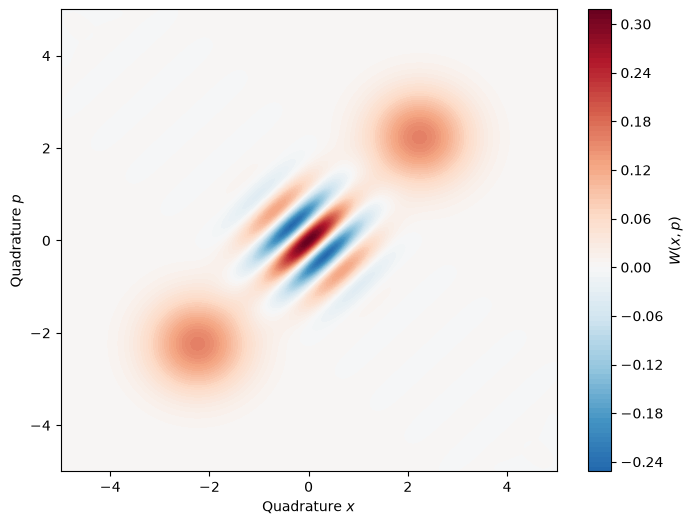

In [3]:
plot_Wigner(state)

In [4]:
# Define sampling parameters
N_angles = 8
N_samples_theta = 1000
x_range = (-5,5)
x_points = 200
x_array = np.linspace(x_range[0],x_range[1],x_points)
# Sample the selected state
thetas, samles = sample_homodyne(state=state,n_angles=N_angles,n_samples_theta=N_samples_theta,
                         bin_data=False,x_vec=x_array)

In [5]:
# Set MLE parameters
N_bins = 40

# Initialize MLE estimator
MLE_estimator = MLE(data=samles, N_bins=N_bins, N_cutoff=N_cutoff)

In [6]:
initial_rho = np.zeros((N_cutoff,N_cutoff))
initial_rho[0,0] = 1.0

R_1 = MLE_estimator.R(initial_rho)

  0%|          | 0/100 [00:00<?, ?it/s]

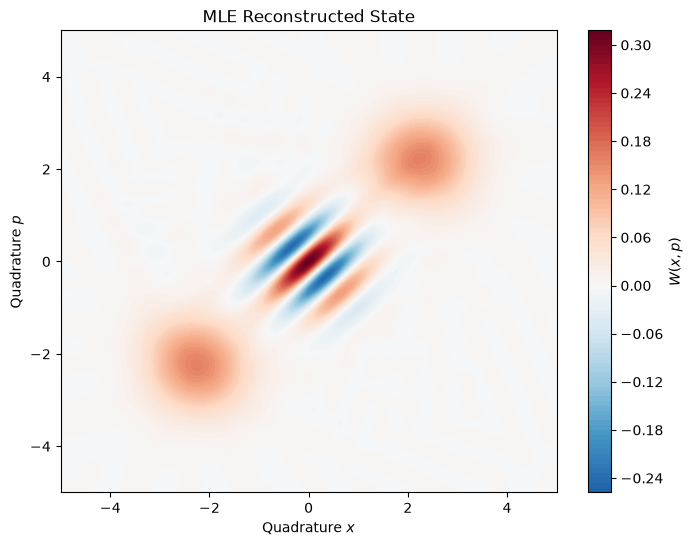

In [7]:
initial_rho = np.zeros((N_cutoff,N_cutoff))
initial_rho[0,0] = 1.0

rho_current = initial_rho
rhos = [rho_current]
for i in tqdm(range(100)):
    rho_current = MLE_estimator.one_iteration(rho_current)
    rhos.append(rho_current)
plot_Wigner(q.Qobj(rhos[-1]), xvec=x_array, title='MLE Reconstructed State')